In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

from sklearn.preprocessing import StandardScaler
from pickle import dump

import math
import glob

# Task 3 - XGboost

### Reading data

In [3]:
dfs = []
for f in glob.glob("../data/SPI_*.csv.zip"):
    dfs.append(pd.read_csv(f))
SPI = pd.concat(dfs)

dfs = []
for f in glob.glob("../data/AOI_*.csv.zip"):
    dfs.append(pd.read_csv(f))
AOI = pd.concat(dfs)

/opt/anaconda3/envs/bigdatalab_cpu_202101/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3427: DtypeWarning: Columns (17) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


### Feature matrix creation

In [4]:
# -------------------------------------------------------------------------------------------------------------------
# AOI data 
# -------------------------------------------------------------------------------------------------------------------

# 1. AOI > PinNumber
AOI['PinNumber'].fillna(0,inplace=True)
AOI.loc[AOI['PinNumber']>2,'PinNumber']=3
AOI['PinNumber']=AOI['PinNumber'].astype(int)

# 2. AOI > AOILabel
AOI['AOILabel']=AOI['AOILabel'].map({'Soldered':1,'UnSoldered':2,'Coplanarity':3,'Translated':4,'LeanSoldering':5})
AOI['AOILabel'].fillna(6,inplace=True)

# 3. AOI > RepairLabel
AOI.dropna(subset=['RepairLabel'],axis=0,inplace=True)
AOI['RepairLabel']=AOI['RepairLabel'].map({'FalseScrap':0, 'NotPossibleToRepair':1, 'NotYetClassified':2})

# 4. AOI > OperatorLabel & MachineID
AOI=AOI.drop('OperatorLabel',axis=1)
del AOI['MachineID']

# 5. AOI > agg
AOI=pd.get_dummies(AOI,columns=['PinNumber','AOILabel'])

aggs={}
dummy_cols=AOI.columns[4:]
for col in dummy_cols:
    aggs[col]='sum'
    
AOI['AOILabel']=1
aggs['AOILabel']=['count']
aggs['RepairLabel']=['mean']

AOI_agg=AOI.groupby(['PanelID','FigureID','ComponentID']).agg(aggs)
AOI_agg.columns=AOI_agg.columns.map('_'.join)
AOI_agg=AOI_agg.reset_index()

AOI_agg.rename(columns={'RepairLabel_mean':'RepairLabel'},inplace=True)

# -------------------------------------------------------------------------------------------------------------------
# SPI data 
# -------------------------------------------------------------------------------------------------------------------

# SPI > Result
SPI['Result']=SPI['Result'].map({'GOOD':0})
SPI['Result'].fillna(1,inplace=True)


# SPI > NaN
SPI.dropna(inplace=True)
SPI.reset_index(inplace=True,drop=True)


# SPI > Date, Time
SPI.drop(['Date','Time'],axis=1,inplace=True)


# SPI > dtype
SPI['Shape(um)']=SPI['Shape(um)'].astype(float)

# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Feature Creation
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

SPI['offset_x_y']       = np.sqrt(SPI['OffsetX(%)']**2+SPI['OffsetY(%)']**2)

SPI['size_x_y']         = np.sqrt(SPI['SizeX']**2+SPI['SizeY']**2)

SPI['vol_area_ratio']   = SPI['Volume(%)']/SPI['Area(%)']

SPI['volmu_vol%_ratio'] = SPI['Area(um2)']/SPI['Volume(%)']
SPI = SPI.fillna(0)

SPI['posx_posy']           = np.sqrt(SPI['PosX(mm)']**2+SPI['PosY(mm)']**2)

SPI['ratio_offset_x_y']    = SPI['OffsetX(%)']/SPI['OffsetY(%)']
SPI['ratio_offset_x_y']    = SPI['ratio_offset_x_y'].replace([np.inf, -np.inf], 0)
SPI['ratio_offset_x_y']    = SPI['ratio_offset_x_y'].fillna(0)

SPI['ratio_offset_size_x'] = SPI['OffsetX(%)']/SPI['SizeX']

SPI['ratio_offset_size_y'] = SPI['OffsetY(%)']/SPI['SizeY']

SPI['volume%_offset%_ratio'] = SPI['Volume(%)']/SPI['OffsetX(%)']
SPI['volume%_offset%_ratio'] = SPI['volume%_offset%_ratio'].fillna(0)
SPI['volume%_offset%_ratio'] = SPI['volume%_offset%_ratio'].replace([np.inf, -np.inf], 0)

SPI['sizey_posy_ratio'] = SPI['SizeY']/SPI['PosY(mm)']
SPI['sizey_posy_ratio'] = SPI['sizey_posy_ratio'].replace([np.inf, -np.inf], 0)

SPI['posx_posy_ratio'] = SPI['PosX(mm)']/SPI['PosY(mm)']
SPI['posx_posy_ratio'] = SPI['posx_posy_ratio'].fillna(0)

# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# STANDARDIZING
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

numeric_features=SPI[['Volume(%)', 'Height(um)', 'Area(%)', 'OffsetX(%)', 'OffsetY(%)',
       'SizeX', 'SizeY', 'Volume(um3)', 'Area(um2)', 'Shape(um)', 'PosX(mm)',
                     'PosY(mm)', 'offset_x_y', 'size_x_y', 'vol_area_ratio', 'volmu_vol%_ratio',
                     'posx_posy', 'ratio_offset_x_y', 'ratio_offset_size_x', 'ratio_offset_size_y',
                     'volume%_offset%_ratio', 'sizey_posy_ratio', 'posx_posy_ratio']].copy()

scaler = StandardScaler()
X_sc=scaler.fit_transform(numeric_features)

# save the scaler
#dump(scaler, open('task3_scaler_v3.pkl', 'wb'))


SPI.loc[:,['Volume(%)', 'Height(um)', 'Area(%)', 'OffsetX(%)','OffsetY(%)', 'SizeX', 'SizeY', 'Volume(um3)', 'Area(um2)', 'Shape(um)', 
           'PosX(mm)','PosY(mm)', 'offset_x_y', 'size_x_y', 'vol_area_ratio', 'volmu_vol%_ratio','posx_posy', 'ratio_offset_x_y', 'ratio_offset_size_x', 
           'ratio_offset_size_y', 'volume%_offset%_ratio', 'sizey_posy_ratio', 'posx_posy_ratio']]=X_sc.copy()

# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# SPI > PinNumber
SPI['PinNumber']=SPI['PinNumber'].replace({'THERMAL1':"999"})

SPI['PinNumber']=SPI['PinNumber'].astype(int)
SPI['PinNumber']=SPI['PinNumber'].map({1:1, 2:2, 3:3, 4:4, 5:5, 6:6})
SPI['PinNumber'].fillna(7, inplace=True)


# SPI > PadType
SPI=pd.get_dummies(SPI,columns=['PadType'])


# SPI > agg (Making component level feature)
num_columns=['Volume(%)', 'Height(um)',
       'Area(%)', 'OffsetX(%)', 'OffsetY(%)', 'SizeX', 'SizeY', 'Volume(um3)',
       'Area(um2)', 'Shape(um)', 'PosX(mm)', 'PosY(mm)','offset_x_y', 'size_x_y',
       'vol_area_ratio', 'volmu_vol%_ratio', 'posx_posy', 'ratio_offset_x_y',
       'ratio_offset_size_x', 'ratio_offset_size_y', 'volume%_offset%_ratio',
       'sizey_posy_ratio', 'posx_posy_ratio']
aggs={}
for col in num_columns:
    aggs[col]=['mean','sum','std','max','min']
aggs['PinNumber']=['median','count']
aggs['PadType_0.0']=['sum']
aggs['PadType_10.0']=['sum']

SPI_agg=SPI.groupby(['PanelID','FigureID','ComponentID']).agg(aggs)
SPI_agg.columns=SPI_agg.columns.map('_'.join)
SPI_agg=SPI_agg.reset_index()

for col in num_columns:
    SPI_agg[col+'_p2p']=SPI_agg[col+'_max']-SPI_agg[col+'_min']

SPI_agg.dropna(inplace=True)

# SPI > dtype
SPI_agg['FigureID']=SPI_agg['FigureID'].astype(int)


# -------------------------------------------------------------------------------------------------------------------
# SPI + AOI 
# -------------------------------------------------------------------------------------------------------------------

AOI_SPI_agg=AOI_agg.merge(SPI_agg,how='left',on=['PanelID','FigureID','ComponentID'])

AOI_SPI_agg.dropna(inplace=True)

# Export to CSV
#AOI_SPI_agg.to_csv('task3_feature_matrix_v3.csv',index=False)


### Modeling

In [5]:
#input the feature matrix here with unique combination of PanelID, FigureID	and ComponentID
df=AOI_SPI_agg.copy()

In [6]:
df.head()

,PanelID,FigureID,ComponentID,PinNumber_0_sum,PinNumber_1_sum,PinNumber_2_sum,PinNumber_3_sum,AOILabel_1.0_sum,AOILabel_2.0_sum,AOILabel_3.0_sum,...,size_x_y_p2p,vol_area_ratio_p2p,volmu_vol%_ratio_p2p,posx_posy_p2p,ratio_offset_x_y_p2p,ratio_offset_size_x_p2p,ratio_offset_size_y_p2p,volume%_offset%_ratio_p2p,sizey_posy_ratio_p2p,posx_posy_ratio_p2p
0,25319088000520102844,3,TRB3,0,0,1,0,0,0,0,...,0.000000,0.549349,0.001734,0.041759,0.007054,0.275757,0.499407,0.024026,0.005803,0.047612
1,25319088000520102844,6,U3,0,0,0,1,0,0,0,...,0.374544,1.165382,0.003527,0.184099,1.198785,3.026529,2.264866,1.901448,0.347058,0.069802
2,26319048400520102844,6,BC4,0,0,1,0,0,1,0,...,0.000000,0.421700,0.316488,0.096404,0.074165,0.003728,0.002847,0.323763,0.000000,0.026713
3,26319049200520102844,3,C21,3,1,2,0,1,0,1,...,0.000000,0.508156,0.007864,0.026234,0.008821,0.006848,0.029074,0.000488,0.000000,0.011714
4,26319054900520102844,8,RA1,1,0,0,0,0,0,1,...,0.027187,0.903896,0.012627,0.025129,0.118509,1.257689,0.225909,0.164129,0.003045,0.006784


In [7]:
# Eliminate data "RepairLabel" = 2(NotYetClassified)
df = df[df['RepairLabel'] != 2]

In [8]:
X = df.drop(['PanelID','FigureID','ComponentID','RepairLabel'],axis=1)

y = df['RepairLabel'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42) 

In [9]:
import xgboost as xgb

#From Example2
model2 = xgb.XGBClassifier(n_estimators=100, max_depth=8, learning_rate=0.1, subsample=0.5)
train_model2 = model2.fit(X_train, y_train)

In [10]:
# Score Report for Training data

y_pred = model2.predict(X_train)
y_true = y_train.copy()

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, fbeta_score

accuracy_score  = accuracy_score(y_true, y_pred)
error_rate      = 1 - accuracy_score
recall_score    = recall_score(y_true, y_pred)
precision_score = precision_score(y_true, y_pred)
f1_score        = f1_score(y_true, y_pred)
fbeta_score     = fbeta_score(y_true, y_pred, beta=0.1)

print("---Report for Train data ---")
print("Accuracy:  %.2f" % (accuracy_score*100))
print("Error_rate: %.2f" % (error_rate*100))
print("Recall:    %.2f" % (recall_score*100))
print("Precision: %.2f" % (precision_score*100))
print("F1:        %.2f" % (f1_score*100))
print("F_beta:    %.2f" % (fbeta_score*100))

---Report for Train data ---
Accuracy:  99.57
Error_rate: 0.43
Recall:    100.00
Precision: 99.36
F1:        99.68
F_beta:    99.37


In [11]:
# Score Report for Training data

y_pred = model2.predict(X_test)
y_true = y_test.copy()

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, fbeta_score

accuracy_score  = accuracy_score(y_true, y_pred)
error_rate      = 1 - accuracy_score
recall_score    = recall_score(y_true, y_pred)
precision_score = precision_score(y_true, y_pred)
f1_score        = f1_score(y_true, y_pred)
fbeta_score     = fbeta_score(y_true, y_pred, beta=0.1)

print("---Report for Train data ---")
print("Accuracy:  %.2f" % (accuracy_score*100))
print("Error_rate: %.2f" % (error_rate*100))
print("Recall:    %.2f" % (recall_score*100))
print("Precision: %.2f" % (precision_score*100))
print("F1:        %.2f" % (f1_score*100))
print("F_beta:    %.2f" % (fbeta_score*100))

---Report for Train data ---
Accuracy:  87.83
Error_rate: 12.17
Recall:    95.65
Precision: 85.71
F1:        90.41
F_beta:    85.80


In [12]:
feature_importances_xgb=model2.feature_importances_
feature_importance_xgb=pd.DataFrame()
feature_importance_xgb['Value'] = feature_importances_xgb*1000
feature_importance_xgb['Feature'] = X_train.columns
feature_importance_xgb.sort_values(by='Value',ascending=False,inplace=True)


Bad key "text.kerning_factor" on line 4 in
/opt/anaconda3/envs/bigdatalab_cpu_202101/lib/python3.7/site-packages/matplotlib/mpl-data/stylelib/_classic_test_patch.mplstyle.
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.1.2/matplotlibrc.template
or from the matplotlib source distribution


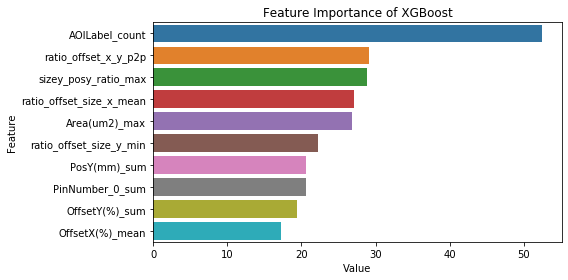

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

plt.figure(figsize=(8, 4))
sns.barplot(x="Value", y="Feature",data=feature_importance_xgb[0:10])
plt.title('Feature Importance of XGBoost')
plt.tight_layout()
plt.show()

In [14]:
feature_importance_xgb[0:15]

,Value,Feature
10,52.483154,AOILabel_count
147,29.140060,ratio_offset_x_y_p2p
119,28.806993,sizey_posy_ratio_max
101,27.126574,ratio_offset_size_x_mean
54,26.870625,Area(um2)_max
110,22.225485,ratio_offset_size_y_min
67,20.601088,PosY(mm)_sum
0,20.575768,PinNumber_0_sum
32,19.388201,OffsetY(%)_sum
26,17.248594,OffsetX(%)_mean


In [13]:
import pickle
filename = 'task3_model_XGboost_v3.sav'
# save the model to disk (uncomment to save the model)
#pickle.dump(model2, open(filename, 'wb')) 

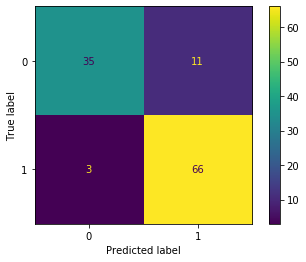

--- Report ---
TPR:  76.09
TNR:  95.65
FPR:  4.35
FNR:  23.91


In [14]:
# Confusion Matrix

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Need to be Editted ######
# y_true = 
# y_pred =
############################

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm) #, display_labels=clf.classes_)
disp.plot()
plt.show()

#---------------------------------------------------------------------------------------

confusion_matrix = cm

FP = confusion_matrix.sum(axis=0) - np.diag(confusion_matrix)  
FN = confusion_matrix.sum(axis=1) - np.diag(confusion_matrix)
TP = np.diag(confusion_matrix)
TN = confusion_matrix.sum() - (FP + FN + TP)

# Sensitivity, hit rate, recall, or true positive rate
TPR = TP/(TP+FN)
# Specificity or true negative rate
TNR = TN/(TN+FP) 
# Precision or positive predictive value
PPV = TP/(TP+FP)
# Negative predictive value
NPV = TN/(TN+FN)
# Fall out or false positive rate
FPR = FP/(FP+TN)
# False negative rate
FNR = FN/(TP+FN)
# False discovery rate
FDR = FP/(TP+FP)

# Overall accuracy
ACC = (TP+TN)/(TP+FP+FN+TN)

#---------------------------------------------------------------------------------------

# Overall accuracy
TP = TP[0]
TN = TN[0]
FP = FP[0]
FN = FN[0]

# Sensitivity, hit rate, recall, or true positive rate
TPR = TP/(TP+FN)
# Specificity or true negative rate
TNR = TN/(TN+FP) 
# Fall out or false positive rate
FPR = FP/(FP+TN)
# False negative rate
FNR = FN/(TP+FN)

print("--- Report ---")
print("TPR:  %.2f" % (TPR*100))
print("TNR:  %.2f" % (TNR*100))
print("FPR:  %.2f" % (FPR*100))
print("FNR:  %.2f" % (FNR*100))



#---------------------------------------------------------------------------------------
